In [167]:
import requests
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
import seaborn as sns



In [168]:

 
# Toronto Open Data is stored in a CKAN instance. It's APIs are documented here:
# https://docs.ckan.org/en/latest/api/
 
# To hit our API, you'll be making requests to:
base_url = "https://ckan0.cf.opendata.inter.prod-toronto.ca"
 
# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
url = base_url + "/api/3/action/package_show"
params = { "id": "neighbourhood-crime-rates"}
#package = requests.get(url, params = params).json()

In [169]:
# Fetch the package data
response = requests.get(url, params=params)

# Check if the request was successful
if response.status_code == 200:
    package = response.json()

    # Iterate through resources
    for idx, resource in enumerate(package["result"]["resources"]):
        # For datastore_active resources
        if resource["datastore_active"]:
            # Get all records in CSV format
            dump_url = base_url + "/datastore/dump/" + resource["id"]
            resource_dump_data = requests.get(dump_url)

            # Check if the dump request was successful
            if resource_dump_data.status_code == 200:
                # Write the CSV data to a file
                csv_filename = f"resource_{idx}.csv"
                with open(csv_filename, "w", newline="", encoding="utf-8") as csv_file:
                    csv_file.write(resource_dump_data.text)
                print(f"Data successfully written to {csv_filename}")
            else:
                print(f"Failed to retrieve data for resource {idx}. Status code: {resource_dump_data.status_code}")
else:
    print(f"Failed to retrieve package. Status code: {response.status_code}")

Data successfully written to resource_0.csv


In [170]:

# Load the CSV file into a DataFrame
df = pd.read_csv('resource_0.csv')



In [171]:
print (df.columns)

for column in df.columns:
    print(column)

Index(['_id', 'AREA_NAME', 'HOOD_ID', 'ASSAULT_2014', 'ASSAULT_2015',
       'ASSAULT_2016', 'ASSAULT_2017', 'ASSAULT_2018', 'ASSAULT_2019',
       'ASSAULT_2020',
       ...
       'THEFTOVER_RATE_2017', 'THEFTOVER_RATE_2018', 'THEFTOVER_RATE_2019',
       'THEFTOVER_RATE_2020', 'THEFTOVER_RATE_2021', 'THEFTOVER_RATE_2022',
       'THEFTOVER_RATE_2023', 'THEFTOVER_RATE_2024', 'POPULATION_2024',
       'geometry'],
      dtype='object', length=203)
_id
AREA_NAME
HOOD_ID
ASSAULT_2014
ASSAULT_2015
ASSAULT_2016
ASSAULT_2017
ASSAULT_2018
ASSAULT_2019
ASSAULT_2020
ASSAULT_2021
ASSAULT_2022
ASSAULT_2023
ASSAULT_2024
ASSAULT_RATE_2014
ASSAULT_RATE_2015
ASSAULT_RATE_2016
ASSAULT_RATE_2017
ASSAULT_RATE_2018
ASSAULT_RATE_2019
ASSAULT_RATE_2020
ASSAULT_RATE_2021
ASSAULT_RATE_2022
ASSAULT_RATE_2023
ASSAULT_RATE_2024
AUTOTHEFT_2014
AUTOTHEFT_2015
AUTOTHEFT_2016
AUTOTHEFT_2017
AUTOTHEFT_2018
AUTOTHEFT_2019
AUTOTHEFT_2020
AUTOTHEFT_2021
AUTOTHEFT_2022
AUTOTHEFT_2023
AUTOTHEFT_2024
AUTOTHEFT_RATE_2014

In [172]:
df_assault = df[['ASSAULT_RATE_2014',
                                'ASSAULT_RATE_2015', 'ASSAULT_RATE_2016',
                                'ASSAULT_RATE_2017', 'ASSAULT_RATE_2018',
                                'ASSAULT_RATE_2019', 'ASSAULT_RATE_2020',
                                'ASSAULT_RATE_2021', 'ASSAULT_RATE_2022',
                                'ASSAULT_RATE_2023', 'ASSAULT_RATE_2024']]

In [173]:
df_assault.columns = ['2014',
                                '2015', '2016',
                                '2017', '2018',
                                '2019', '2020',
                                '2021', '2022',
                                '2023', '2024']

In [174]:
# Convert to long format
df_assault_long = pd.melt(
    df_assault,
    #id_vars=['ID'],           # Keep 'ID' as the identifier
    value_vars=['2014',
                                '2015', '2016',
                                '2017', '2018',
                                '2019', '2020',
                                '2021', '2022',
                                '2023', '2024'],  # Columns to unpivot
    var_name='Year',          # Name for the new variable column
    value_name='Assault_Rate'        # Name for the new value column
)

print("Long Format:")
print (df_assault_long.head(6))


Long Format:
   Year  Assault_Rate
0  2014    301.171844
1  2014    455.757172
2  2014    456.150665
3  2014    698.258606
4  2014   3750.000000
5  2014    764.067383


We will now make side by side boxplots for the Assault Rate data, using Seaborn.

Text(0.125, -0.05, 'Figure 1: Box plots showing the distribution of Assault rates in Toronto from 2014 to 2024.\n Assault Rates are calculated as the number of assaults per 100,000 people per year for all\n 158 neighborhoods of the city of Toronto')

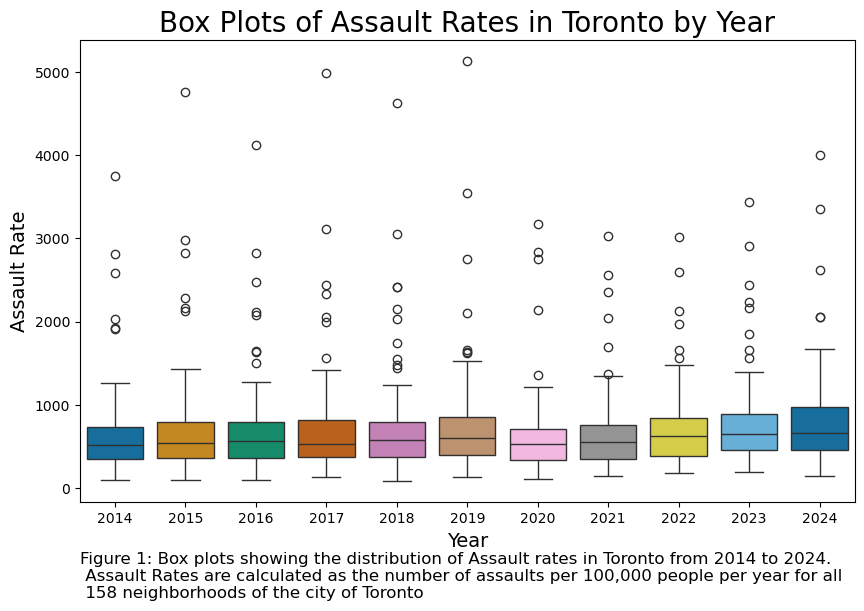

In [175]:
# Set a colorblind-friendly palette
sns.set_palette('colorblind')
# Using custom font styles for the plot
font1 = {'family':'sans-serif','color':'black','size': 20}
font2 = {'family':'sans-serif','color':'black','size':14}
font3 = {'family':'sans-serif','color':'black','size':12}


plt.figure(figsize=(10, 6))  # Set the figure size
sns.boxplot(x='Year', y='Assault_Rate', hue = 'Year', data=df_assault_long, palette = 'colorblind', legend = False)  # Create box plots
plt.title('Box Plots of Assault Rates in Toronto by Year', fontdict = font1, loc = 'center')  # Add a title
plt.xlabel('Year', fontdict = font2)  # Label for the x-axis
plt.ylabel('Assault Rate', fontdict = font2)  # Label for the y-axis

# Add a tag below the figure
plt.figtext(0.125, -0.05, 'Figure 1: Box plots showing the distribution of Assault rates in Toronto from 2014 to 2024.\n Assault Rates are calculated as the number of assaults per 100,000 people per year for all\n 158 neighborhoods of the city of Toronto', ha='left', fontdict = font3)


Python and seaborn were used to create the figure. The audience comprises anyone interested in Assault rates in Toronto 

including journalists, law enforcement officers, researchers, and others. 

The information or message that is being conveyed through the figure is, in general, an idea about crime rates in

the city of Toronto from the years 2014 to 2024 through a visual representation of assault rates in the city.

 More specifically, the figure shows a decline in Assault rates in the city of Toronto during the peak of the Covid

 pandemic (2020 and 2021) before rebounding to around or a little more than what it was in 2019.


This plot honestly and accurately displays the distribution of Assault rates for all 158 neighborhoods in the city of Toronto from 

the years 2014 to 2024 thereby satisfying the criterion of substantiveness. The plot makes use of multiple box plots. Aesthetics 

is a matter of taste but if we agree that the box plot is aesthetically appealing than this figure satisfy the aesthetics 

criterion. So long as we understand how to read a box plot the figure satisfies the perceptual quality.

Reproducability was ensured by downloading the dataset using the API given for the Neighborhood Crime Rates Data at the City of 

Toronto's Open Data portal (see https://open.toronto.ca/dataset/neighbourhood-crime-rates/ ). The figure itself was constructed using Python and seaborn in a markdown file 

format thus making the whole exercise reproducable. The color palette used is suitable for color blind people thereby making the 

figure more accessible.

This plot should be of some interest to anyone residing in Toronto or visiting the city of Toronto regularly 

(for instance, those residing in the Greater Toronto Area or just outside the Greater Toronto Area) since anyone can become a 

victim of assault. 

Out of all the information in the dataset, Assault Rates were focussed on in this figure since they seemed to be a good indicator of crime rate.

With respect to 'underwater labor', a tip of the hat to those who collected this data and posted it online. Presumably this 

was the work of people working for law enforcement for the City of Toronto.

